<a href="https://colab.research.google.com/github/will2bless1140/Data-science/blob/main/Machine%20Learning%20for%20Diabetes%20Diagnosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('diabetes.csv')
df.head()
df.tail()
df.sample(10)
df.shape
df.dtypes
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# data cleaning
#drop dublicate
df=df.drop_duplicates()
# after droping duplicate you check the shap again to see if it reduces


In [ ]:
df.shape
# its still the same so no duplicate values

(768, 9)

In [ ]:
# check for null values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
# check for the number of zero values
print('No of zero values in Pregnancies',df[df['Pregnancies']==0].shape[0])

No of zero values in Pregnancies 111


In [ ]:
print('No of zero values in Glucose',df[df['Glucose']==0].shape[0])

No of zero values in Glucose 5


In [ ]:
print('No of zero values in BloodPressure',df[df['BloodPressure']==0].shape[0])

No of zero values in BloodPressure 35


In [ ]:
print('No of zero values in SkinThickness',df[df['SkinThickness']==0].shape[0])

No of zero values in SkinThickness 227


In [ ]:
print('No of zero values in Insulin',df[df['Insulin']==0].shape[0])

No of zero values in Insulin 374


In [ ]:
print('No of zero values in BMI',df[df['BMI']==0].shape[0])

No of zero values in BMI 11


In [ ]:
# replacing no of zero values with mean of that columns
df['Pregnancies']=df['Pregnancies'].replace(0,df['Pregnancies'].mean())
df['Glucose']=df['Glucose'].replace(0,df['Glucose'].mean())
df['BloodPressure']=df['BloodPressure'].replace(0,df['BloodPressure'].mean())
df['SkinThickness']=df['SkinThickness'].replace(0,df['SkinThickness'].mean())
df['Insulin']=df['Insulin'].replace(0,df['Insulin'].mean())
df['BMI']=df['BMI'].replace(0,df['BMI'].mean())

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,4.400782,121.681605,72.254807,26.606479,118.660163,32.450805,0.471876,33.240885,0.348958
std,2.984162,30.436016,12.115932,9.631241,93.080358,6.875374,0.331329,11.760232,0.476951
min,1.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,2.000000,99.750000,64.000000,20.536458,79.799479,27.500000,0.243750,24.000000,0.000000
50%,3.845052,117.000000,72.000000,23.000000,79.799479,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Negative (0):  500
positive (1):  268


/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


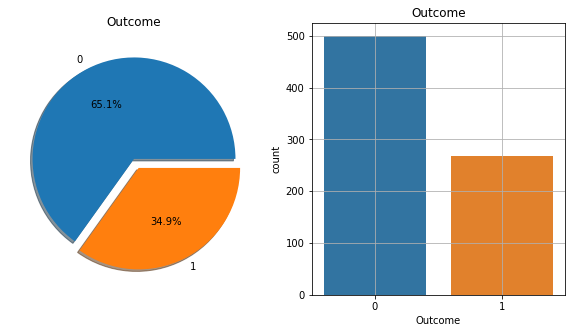

In [ ]:
# data visualization
# count plot
f,ax=plt.subplots(1,2,figsize=(10,5))
df['Outcome'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Outcome')
ax[0].set_ylabel('')
sns.countplot('Outcome',data=df,ax=ax[1])
ax[1].set_title('Outcome')
N,P = df['Outcome'].value_counts()
print('Negative (0): ',N)
print('positive (1): ',P)
plt.grid()
plt.show()


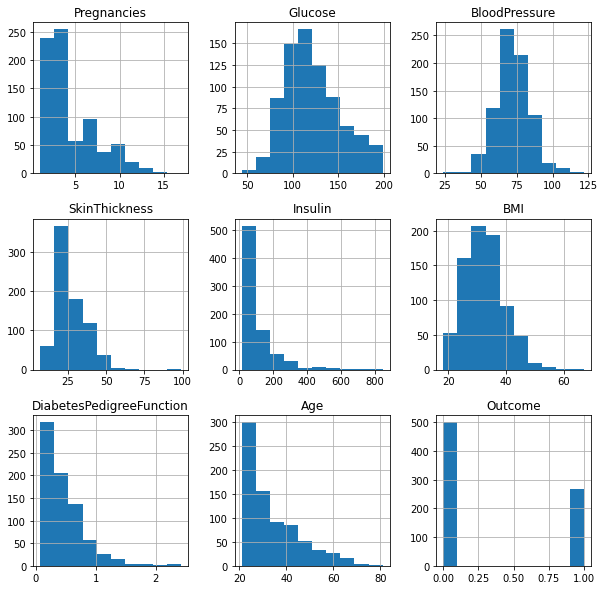

In [ ]:
# there is so much difference so it is imbalance. so we use undersampling

# histogram
df.hist(bins=10, figsize=(10,10))
plt.show()

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f193a6fbf10>,
      dtype=object)

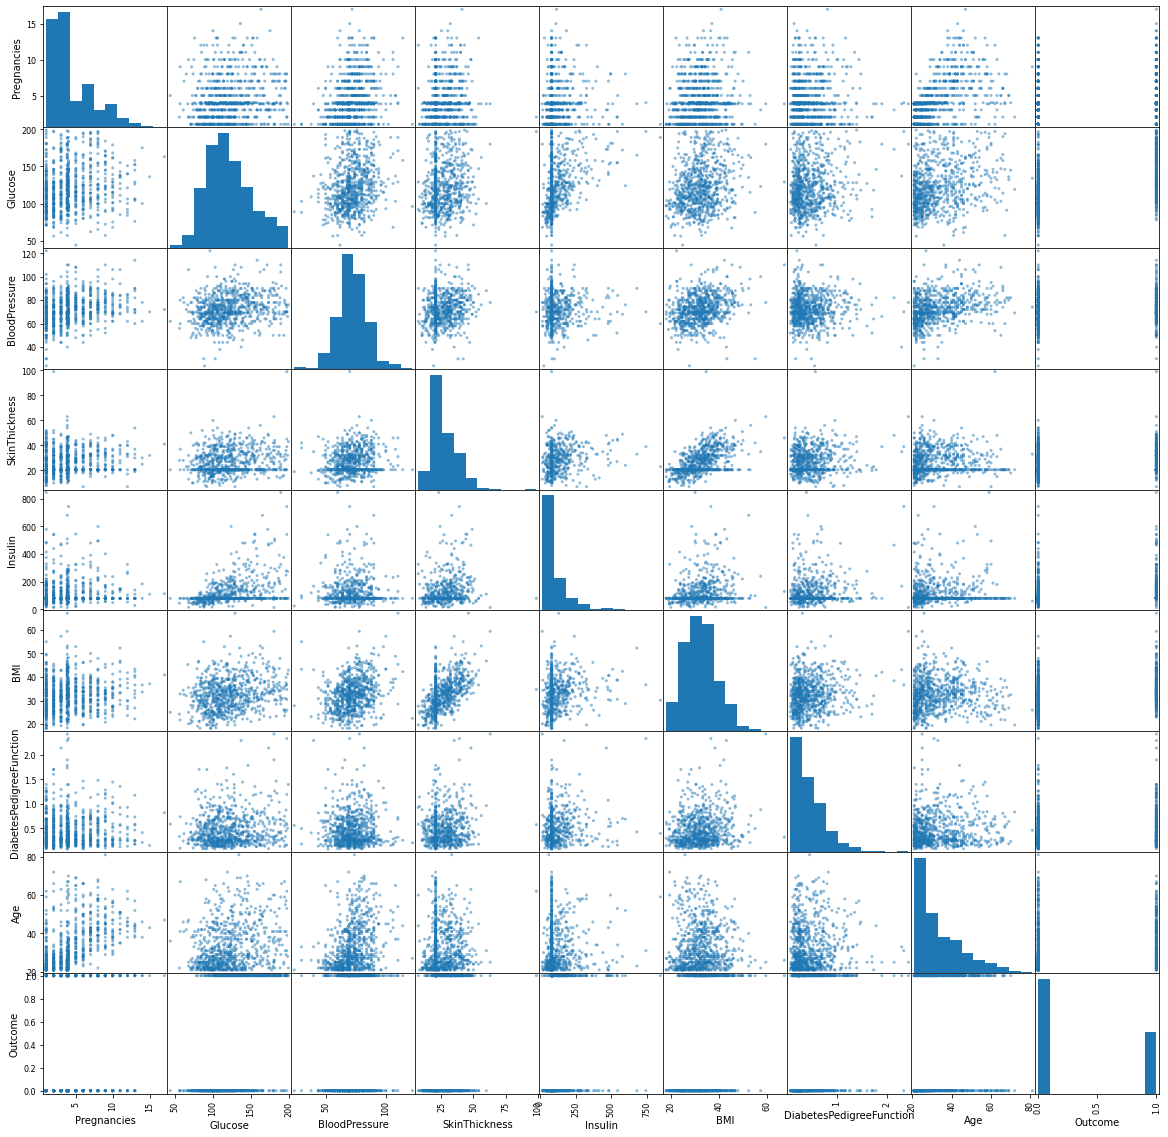

In [ ]:
# scatter plot
from pandas.plotting import scatter_matrix
scatter_matrix(df, figsize =(20,20))

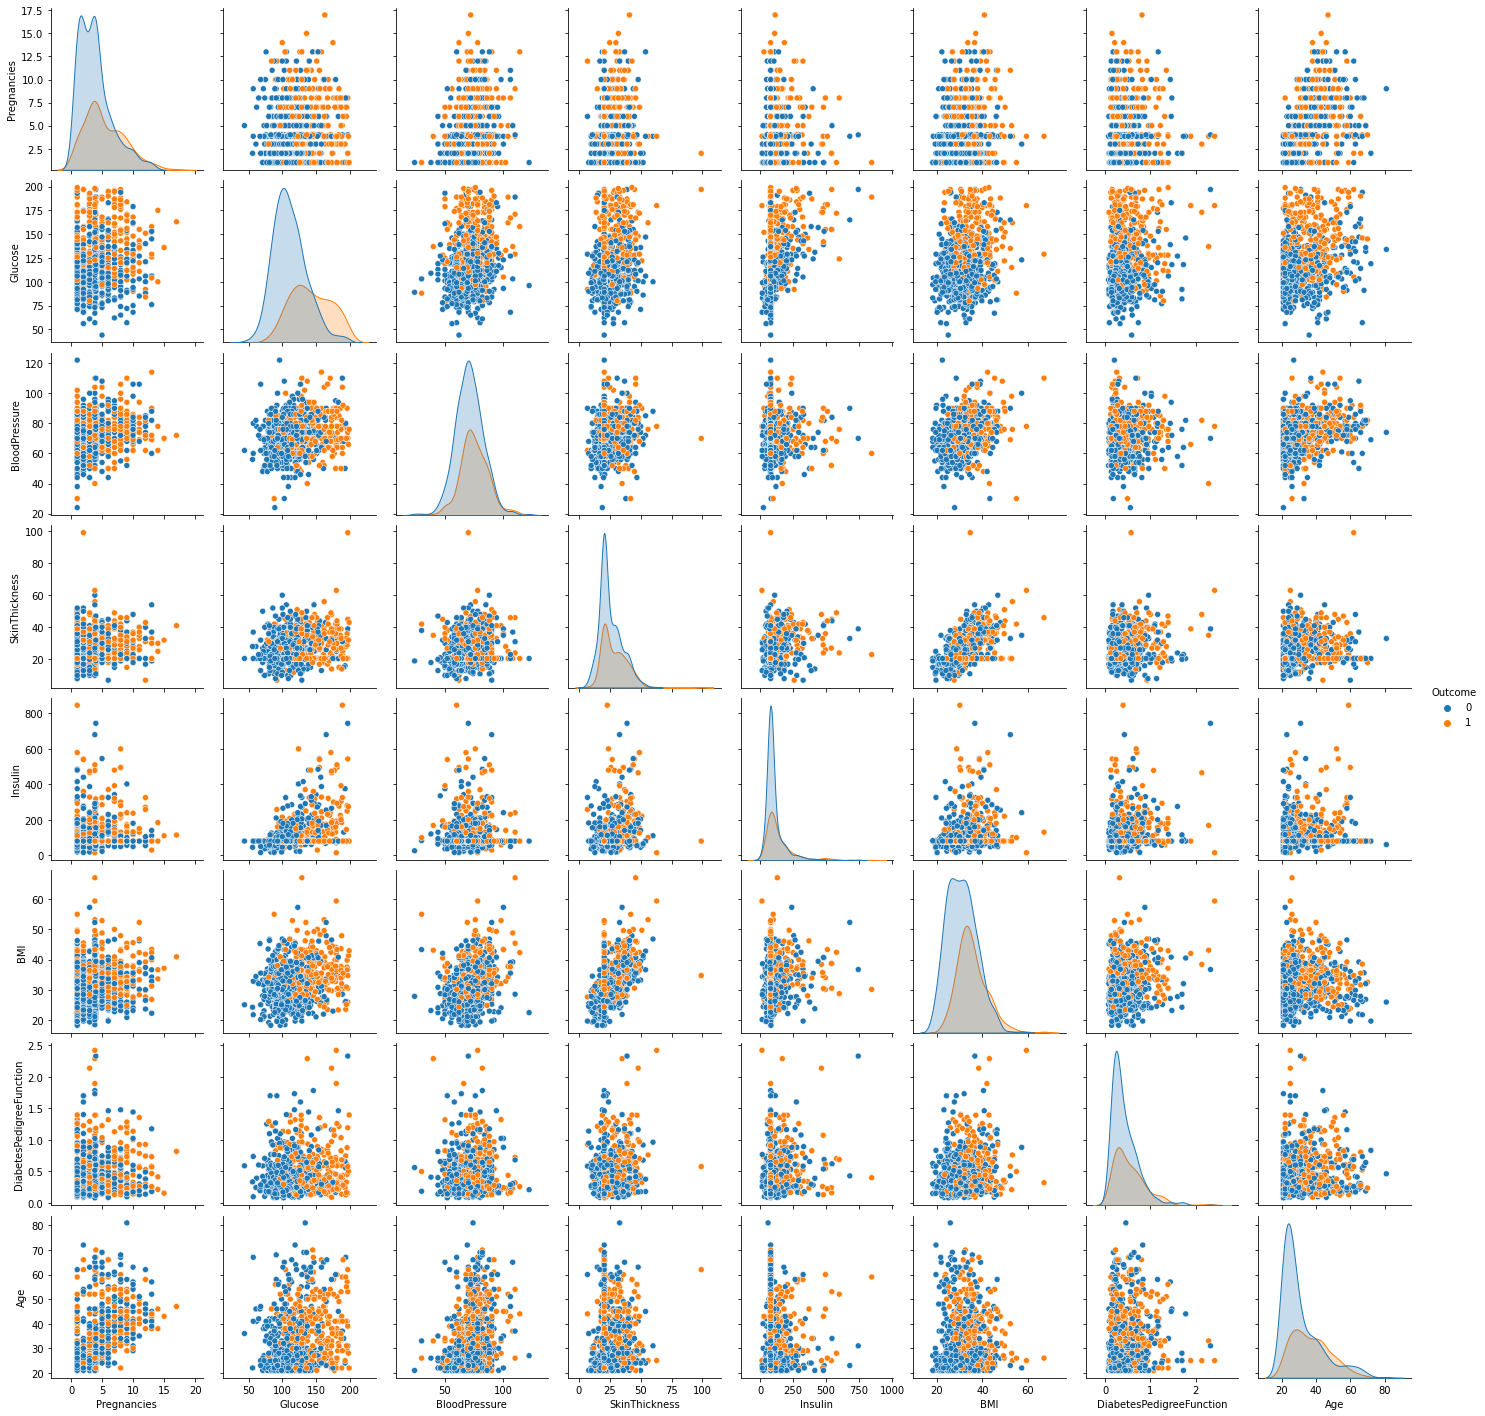

In [ ]:
#pair plot
sns.pairplot(data = df, hue='Outcome')
plt.show()

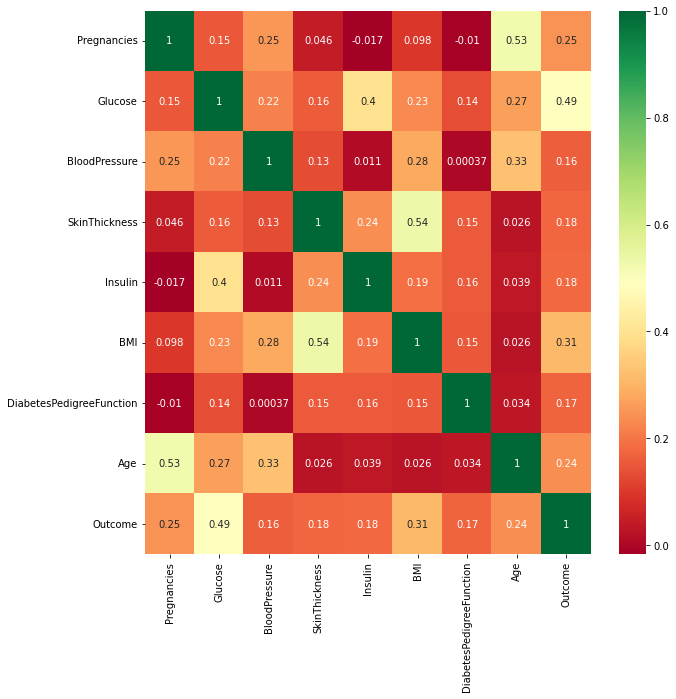

In [ ]:
# correlation analysis is used to quantify the degree to which two variable are related. through the corolation analysis. you evaluate coefficient that tells you how much one variable changes when the other one does. correlation analysis provide you wuth linear relationship between two variables. when we consider feature variables wit the taregt variable, we get to know that how much dependancy is there between particular feature variables and target variables.
import seaborn as sns
corrmat = df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(10,10))
# plot heat map
g=sns.heatmap(df[top_corr_features].corr(),annot=True,cmap='RdYlGn')

In [ ]:
# from the corrolation heat map, we can see that there us high correlation outcome and [pregnancies,glucose,bmi,age,insulin]. we can select these features to accept input from the user and predict the outcome

In [ ]:
# spliting data into x and y
target_name = 'Outcome'
# seprate object for target feature
y = df[target_name]
# seprate object for input feature
x = df.drop(target_name,axis=1)

In [ ]:
# applying feature scaling technique
# there are standard scaler, normalizer,minimax scaler and biarizer

In [ ]:
#standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x)
ssx = scaler.transform(x)
# ssx means standard scaler for x

In [ ]:
#VIF determines the strength of the correlation between the independent variables
# this is the score of an independent variable represent how well the variable is explained by other independent variables
#vif  that starts at 1 has no upper limit
# vif = 1, no correlation between the independent variable and the others variables
# vif exceeding 5 or 10 indicates high multicollinearity between this independent variabler and the others
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif= pd.DataFrame()
vif['vif']= [variance_inflation_factor(ssx,i) for i in range(ssx.shape[1])]
vif['Feautures']= x.columns


In [ ]:
# we will have to remove any value that is greater than 10
vif

,vif,Feautures
0,1.410013,Pregnancies
1,1.347415,Glucose
2,1.252549,BloodPressure
3,1.450493,SkinThickness
4,1.264171,Insulin
5,1.559203,BMI
6,1.056273,DiabetesPedigreeFunction
7,1.546208,Age


In [ ]:
#df.drop(df.columns[[5,6,17,18]], axis=1, inplace=True)

In [ ]:
# next is train test split
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test = train_test_split(ssx,y,test_size=0.2,random_state=7)

In [ ]:
x_train.shape,y_train.shape

In [ ]:
x_test.shape,y_test.shape

In [ ]:
# building the classification algorithms
# logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(solver='liblinear',multi_class='ovr')
lr.fit(x_train,y_train)

In [ ]:
# kneighborsclassifier(KNN)
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)

In [ ]:
# naive-bayes classifier
from sklearn.naive_bayes import GaussianNB
nb= GaussianNB()
nb.fit(x_train, y_train)

In [ ]:
# support vector machine svm
from sklearn.svm import SVC
sv = SVC()
sv.fit(x_train,y_train)

In [ ]:
# decision tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)

In [ ]:
#random forest
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(criterion='entropy')
rf.fit(x_train,y_train)

In [ ]:
# next is to make prediction

In [ ]:
x_test.shape

In [ ]:
# making prediction usinf logistic regression
lr_pred=lr.predict(x_test)
lr_pred.shape

In [ ]:
# making prediction using KNN
knn_pred=knn.predict(x_test)
knn_pred.shape

In [ ]:
# making prediction using naivie bayes
nb_pred=nb.predict(x_test)

In [ ]:
# making prediction using svm
sv_pred=sv.predict(x_test)

In [ ]:
# making prediction using decision tree
dt_pred=dt.predict(x_test)

In [ ]:
# making prediction using random forest
rf_pred=rf.predict(x_test)

In [ ]:
# model evaluation
#train score and test score
# train score mean

In [ ]:
# train score and test score for logistic regression
from sklearn.metrics import accuracy_score
print('Train Accuracy of logistic regression ', lr.score(x_train,y_train)*100)
print('Accuracy (test) score of logistic regression ', lr.score(x_test,y_test)*100)
print('Accuracy (test) score of logistic regression ', accuracy_score(y_test,lr_pred)*100)



In [ ]:
# train score and test score for knn

print('Train Accuracy of knn ', knn.score(x_train,y_train)*100)
print('Accuracy (test) score of knn  ', knn.score(x_test,y_test)*100)
print('Accuracy (test) score of knn  ', accuracy_score(y_test,knn_pred)*100)



In [ ]:
# train score and test score for naivie bayes

print('Train Accuracy of naivie bayes ', nb.score(x_train,y_train)*100)
print('Accuracy (test) score of naivie bayes  ', nb.score(x_test,y_test)*100)
print('Accuracy (test) score of naivie bayes  ', accuracy_score(y_test,nb_pred)*100)



In [ ]:
# train score and test score for svm

print('Train Accuracy of svm ', sv.score(x_train,y_train)*100)
print('Accuracy (test) score of svm  ', sv.score(x_test,y_test)*100)
print('Accuracy (test) score of svm  ', accuracy_score(y_test,sv_pred)*100)



In [ ]:
# train score and test score for decision tree

print('Train Accuracy of decision tree ', dt.score(x_train,y_train)*100)
print('Accuracy (test) score of decision tree  ', dt.score(x_test,y_test)*100)
print('Accuracy (test) score of decision tree  ', accuracy_score(y_test,dt_pred)*100)



In [ ]:
# train score and test score for random forest

print('Train Accuracy of random forest ', rf.score(x_train,y_train)*100)
print('Accuracy (test) score of random forest  ', rf.score(x_test,y_test)*100)
print('Accuracy (test) score of random forest  ', accuracy_score(y_test,rf_pred)*100)



In [ ]:
# confusion matrix
 #confusion matrices is a table which is used to describe the performance
 #of a classification problem. it visualizes the accuracy of a clissifier by comparing
 #predicted values with acutual values.
 #terms used are true positive(tp), true negative(tn), false positive(fp), false negative(fn)
 #tp: the predicted result is positvie , while it is labeled as positvie
 #tn; the predictied result is negative , while it is laneled negative
 #fp: the predictied result is positive , while it is labled as negative . it calls type i error as well
 #fn: the predicted result is negativem while it is labeld negative. it class tpye ii error a well

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
#confusin matrix of logistic regression
cm=confusion_matrix(y_test,lr_pred)
cm

In [ ]:
sns.heatmap(confusion_matrix(y_test,lr_pred),annot=True,fmt='d')
# this is the confusion matrix graphically

In [ ]:
print('classification report of logic regression:')

In [ ]:
import matplotlib.pyplot as plt
plt.clf()
plt.imshow(cm, interpolation='nearest',cmap=plt.cm.Wistia)
classNames = ['0','1']
plt.title('confusin matrix of logistic regression')
plt.ylabel('Actual(true) values')
plt.xlabel('predicted values')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks,classNames,rotation=45)
plt.yticks(tick_marks,classNames)
s = [['TN','FP'],['FN','TP']]
for i in range(2):
  for j in range(2):
    plt.text(j,i,str(s[i][j])+ '= '+str(cm[i][j]))
plt.show()


In [ ]:
pd.crosstab(y_test,lr_pred, margins=True)

In [ ]:
pd.crosstab(y_test, lr_pred, rownames=['Actual values'], colnames=['predicted values'], margins=True)

In [ ]:
# Precision (PPV- positive predictive value)
# it is the ratio of correctly predicted positvie (tp) observations to the total predicted positive observartion(tp+fp)
TP = 33
FP = 11
TP,FP

In [ ]:
precision = TP/(TP+FP)
precision

In [ ]:
precision_score = TP/float(TP+FP)*100
print('precision score: {0:0.4f}'.format(precision_score))

In [ ]:
from sklearn.metrics import precision_score
print('precision score is: ', precision_score(y_test,lr_pred)*100)
print('Mircro Avarage precision score is:',precision_score(y_test,lr_pred,average='micro')*100)
print('Marcro Avarage precision score is:',precision_score(y_test,lr_pred,average='macro')*100)
print('weighted Avarage precision score is:',precision_score(y_test,lr_pred,average='weighted')*100)
print('precision score on non weighted score is:',precision_score(y_test,lr_pred,average=None)*100)



In [ ]:
print('classification report of logistic regression: \n',classification_report(y_test,lr_pred,digits=4))